# Dataset Exploration: Human Movement

This notebook explores the movement dataset collected for the Adaptive Embodied AI project.

The dataset contains short upper-body movement recordings collected with a webcam and converted into pose-based movement features.

The purpose of this notebook is to:

1. inspect the structure of the dataset
2. check the distribution and duration of trials
3. examine the extracted features
4. compare movement patterns across participants and sessions and
5. identify any issues that should be considered before modelling

The analysis is exploratory and descriptive. It does not evaluate model performance or make claims about generalisation.

## Experimental Design

The dataset is organised into four levels:

* **Participant** — person performing the movements
* **Session** — separate recording session
* **Trial** — one recording of a movement
* **Movement class** — instructed movement

The current dataset contains:

* 2 participants
* 2 sessions per participant
* 25 trials per session
* 5 movement classes
* 5 repetitions of each movement per session

The movement classes are:

* `neutral`
* `raise_arms`
* `lean_left`
* `lean_right`
* `lean_forward`

Each trial contains a short sequence of pose-derived movement features collected from webcam video.


In [1]:
# Imports and load dataset

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/movement")

files = sorted(DATA_DIR.glob("P*_S*.csv"))

if not files:
    raise FileNotFoundError(
        f"No participant/session CSV files found in {DATA_DIR.resolve()}"
    )

frames = [pd.read_csv(file) for file in files]

df = pd.concat(frames, ignore_index=True)

print(f"Files loaded: {len(files)}")
print(f"Dataset shape: {df.shape}")

Files loaded: 4
Dataset shape: (5555, 14)


Each participant/session recording is stored as a separate CSV file and is combined into one dataframe for analysis. Participant, session, and trial identifiers are retained throughout the notebook.

In [2]:
display(df.head())

,participant_id,session_id,trial_id,movement_label,timestamp,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,S01,1,neutral,0.477139,0.338744,0.017358,-0.874145,0.000000,0.000000,0.000000,-0.624261,0.000000,0.000000
1,P01,S01,1,neutral,0.630797,0.338862,0.022957,-0.864459,-0.003592,0.013246,0.089318,-0.636336,0.040932,0.266942
2,P01,S01,1,neutral,0.695674,0.337857,0.030148,-0.855146,-0.003591,0.012815,0.205140,-0.642799,0.016168,0.253859
3,P01,S01,1,neutral,0.764480,0.337441,0.034848,-0.857751,-0.002819,0.003732,0.067970,-0.640996,0.000396,0.031294
4,P01,S01,1,neutral,0.826749,0.337080,0.035076,-0.868766,-0.005175,0.012029,0.210297,-0.645758,-0.005368,0.087362


In [3]:
# Dataset overview

feature_columns = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Participants: {df['participant_id'].nunique()}")
print(
    f"Participant-session combinations: "
    f"{df[['participant_id', 'session_id']].drop_duplicates().shape[0]}"
)
print(
    f"Trials: "
    f"{df[['participant_id', 'session_id', 'trial_id']].drop_duplicates().shape[0]}"
)
print(f"Movement classes: {df['movement_label'].nunique()}")

display(df[["participant_id", "session_id", "trial_id", "movement_label"]]
        .head())

Rows: 5,555
Columns: 14
Participants: 2
Participant-session combinations: 4
Trials: 100
Movement classes: 5


,participant_id,session_id,trial_id,movement_label
0,P01,S01,1,neutral
1,P01,S01,1,neutral
2,P01,S01,1,neutral
3,P01,S01,1,neutral
4,P01,S01,1,neutral


The dataset contains 5,555 frame-level observations across 100 trials. The modelling unit will later be the trial, with each trial represented as a short temporal sequence rather than as independent frames.

In [4]:
# Trial structure

trial_summary = (
    df.groupby(
        ["participant_id", "session_id"],
        as_index=False
    )
    .agg(
        trials=("trial_id", "nunique"),
        movements=("movement_label", "nunique"),
        observations=("trial_id", "size"),
    )
)

display(trial_summary)

,participant_id,session_id,trials,movements,observations
0,P01,S01,25,5,1388
1,P01,S02,25,5,1399
2,P02,S01,25,5,1381
3,P02,S02,25,5,1387


In [5]:
movement_counts = (
    df[
        ["participant_id", "session_id", "trial_id", "movement_label"]
    ]
    .drop_duplicates()["movement_label"]
    .value_counts()
    .sort_index()
)

display(movement_counts)

movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

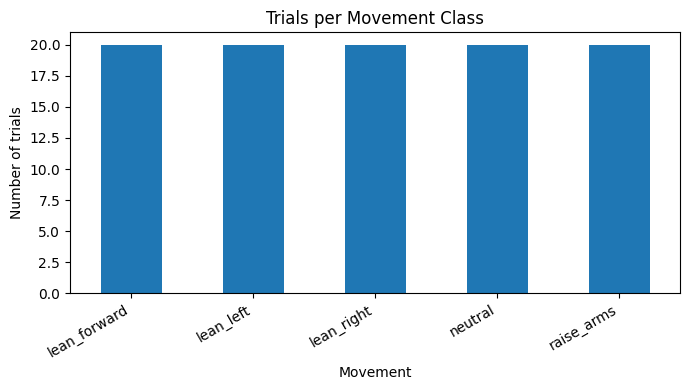

In [6]:
plt.figure(figsize=(7, 4))

movement_counts.plot(kind="bar")

plt.title("Trials per Movement Class")
plt.xlabel("Movement")
plt.ylabel("Number of trials")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
# Temporal structure

trial_stats = (
    df.groupby(
        ["participant_id", "session_id", "trial_id", "movement_label"]
    )
    .agg(
        observations=("timestamp", "size"),
        duration=("timestamp", lambda x: x.max() - x.min()),
    )
    .reset_index()
)

print(
    f"Observations per trial: "
    f"{trial_stats['observations'].min()}–"
    f"{trial_stats['observations'].max()}"
)

print(
    f"Trial duration: "
    f"{trial_stats['duration'].min():.3f}–"
    f"{trial_stats['duration'].max():.3f} s"
)

Observations per trial: 47–60
Trial duration: 3.492–3.625 s


Trials contain 47–60 observations over approximately 3.5–3.6 seconds. Small differences in sequence length are expected from webcam-based acquisition.

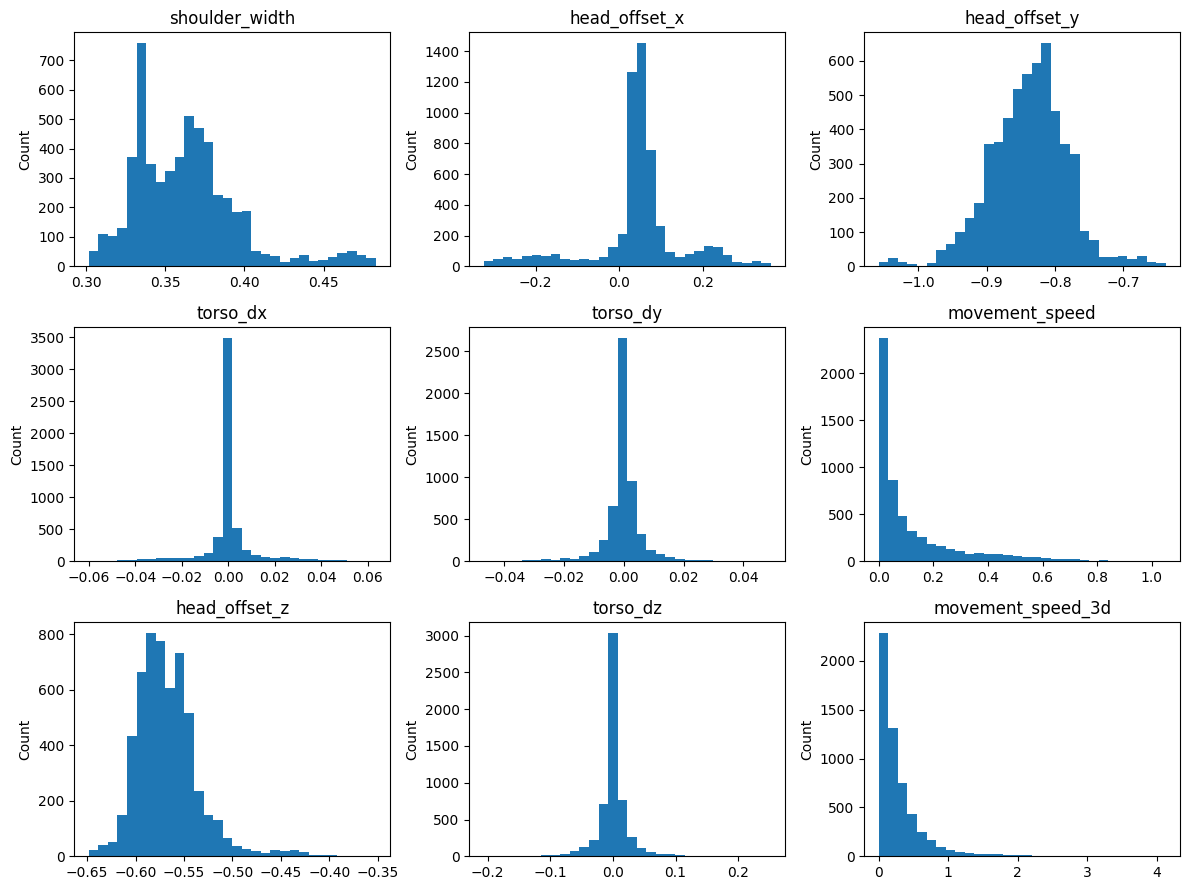

In [8]:
# Feature distributions

fig, axes = plt.subplots(
    3, 3, figsize=(12, 9)
)

for ax, feature in zip(axes.flat, feature_columns):
    ax.hist(df[feature], bins=30)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
display(
    df[feature_columns]
    .describe()
    .T[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(4)
)

,mean,std,min,25%,50%,75%,max
shoulder_width,0.3632,0.0334,0.3017,0.3368,0.3611,0.3787,0.4828
head_offset_x,0.0430,0.1082,-0.3235,0.0287,0.0484,0.0729,0.3610
head_offset_y,-0.8386,0.0566,-1.0578,-0.8733,-0.8353,-0.8036,-0.6379
torso_dx,0.0002,0.0116,-0.0601,-0.0010,0.0000,0.0011,0.0634
torso_dy,-0.0001,0.0071,-0.0469,-0.0017,0.0000,0.0017,0.0492
movement_speed,0.1217,0.1655,0.0000,0.0159,0.0476,0.1557,1.0507
head_offset_z,-0.5669,0.0328,-0.6483,-0.5886,-0.5716,-0.5510,-0.3523
torso_dz,0.0001,0.0266,-0.2064,-0.0062,0.0000,0.0065,0.2518
movement_speed_3d,0.2938,0.3529,0.0000,0.0840,0.1788,0.3731,4.1295


In [10]:
# Movement-specific features

selected_features = [
    "head_offset_x",
    "head_offset_y",
    "head_offset_z",
    "movement_speed_3d",
]

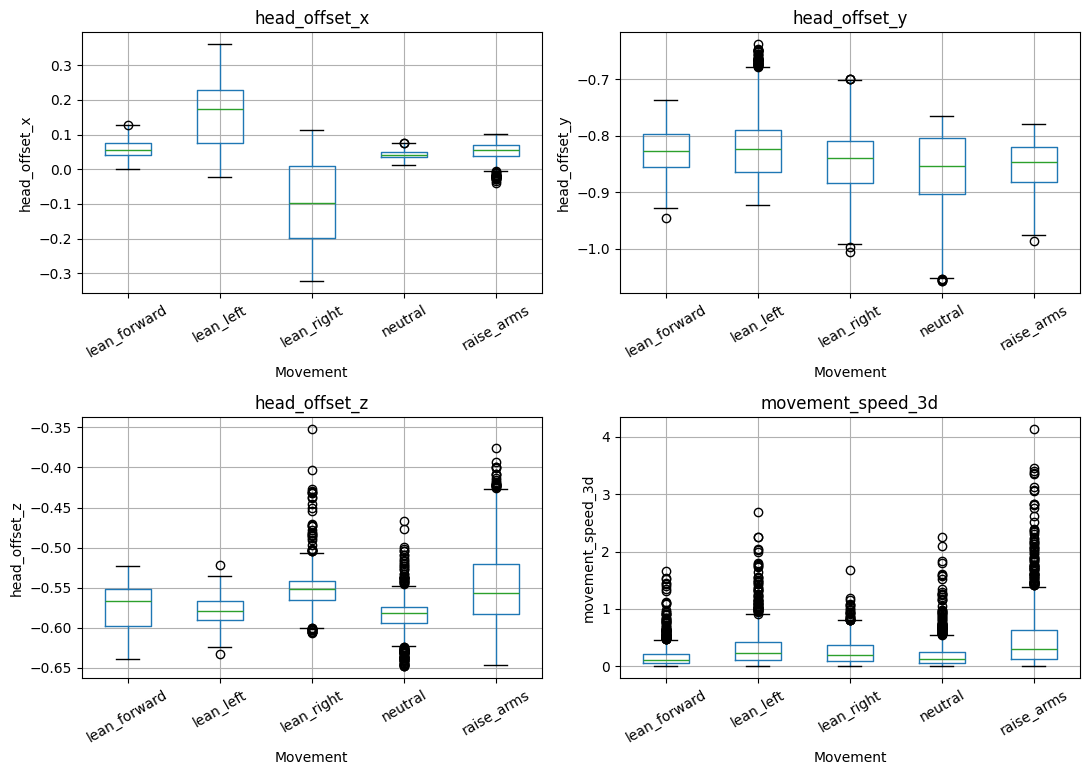

In [11]:
fig, axes = plt.subplots(
    2, 2, figsize=(11, 8)
)

for ax, feature in zip(axes.flat, selected_features):
    df.boxplot(
        column=feature,
        by="movement_label",
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Movement")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("")
plt.tight_layout()
plt.show()

The distributions show that several features vary across movement classes. In particular, lateral head position and 3D movement speed show visible movement-specific differences.

This indicates that the extracted representation contains information related to the instructed movement. However, these plots are descriptive and do not establish classification performance or generalisation.

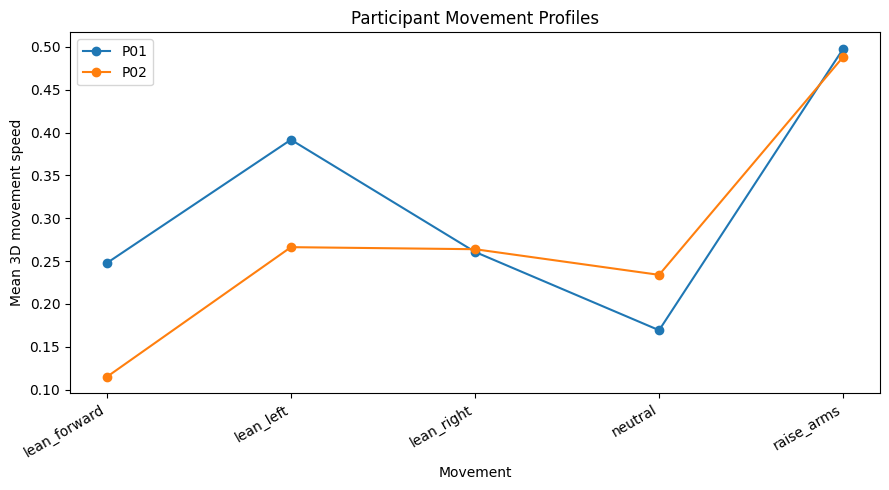

In [12]:
# Participant and session variation

participant_means = (
    df.groupby(
        ["participant_id", "movement_label"]
    )["movement_speed_3d"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

for participant, group in participant_means.groupby("participant_id"):
    plt.plot(
        group["movement_label"],
        group["movement_speed_3d"],
        marker="o",
        label=participant
    )

plt.title("Participant Movement Profiles")
plt.xlabel("Movement")
plt.ylabel("Mean 3D movement speed")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

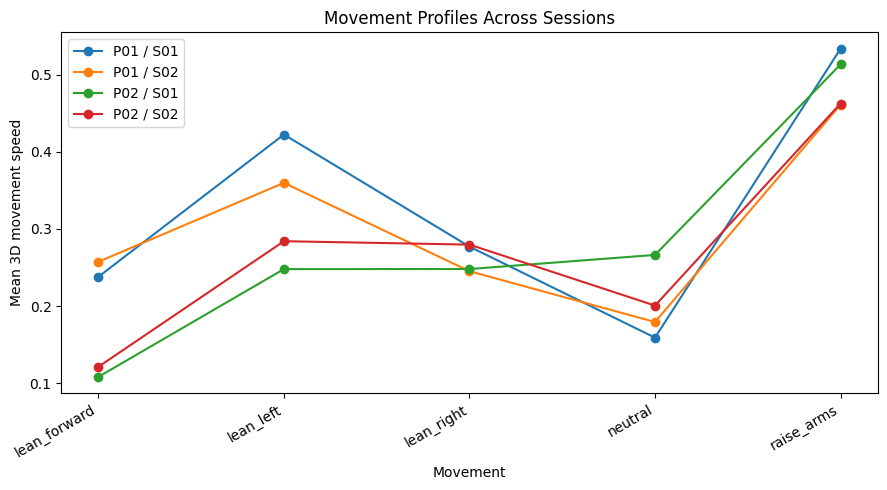

In [13]:
session_means = (
    df.groupby(
        ["participant_id", "session_id", "movement_label"]
    )["movement_speed_3d"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

for (participant, session), group in session_means.groupby(
    ["participant_id", "session_id"]
):
    plt.plot(
        group["movement_label"],
        group["movement_speed_3d"],
        marker="o",
        label=f"{participant} / {session}"
    )

plt.title("Movement Profiles Across Sessions")
plt.xlabel("Movement")
plt.ylabel("Mean 3D movement speed")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

The movement profiles show that the same instructed movement can be expressed with different feature magnitudes across participants. Some variation is also present between sessions of the same participant.

This provides preliminary motivation for investigating personalised modelling. At the same time, the experiment currently contains only two participants, so these observations should not be interpreted as evidence of a general participant effect.

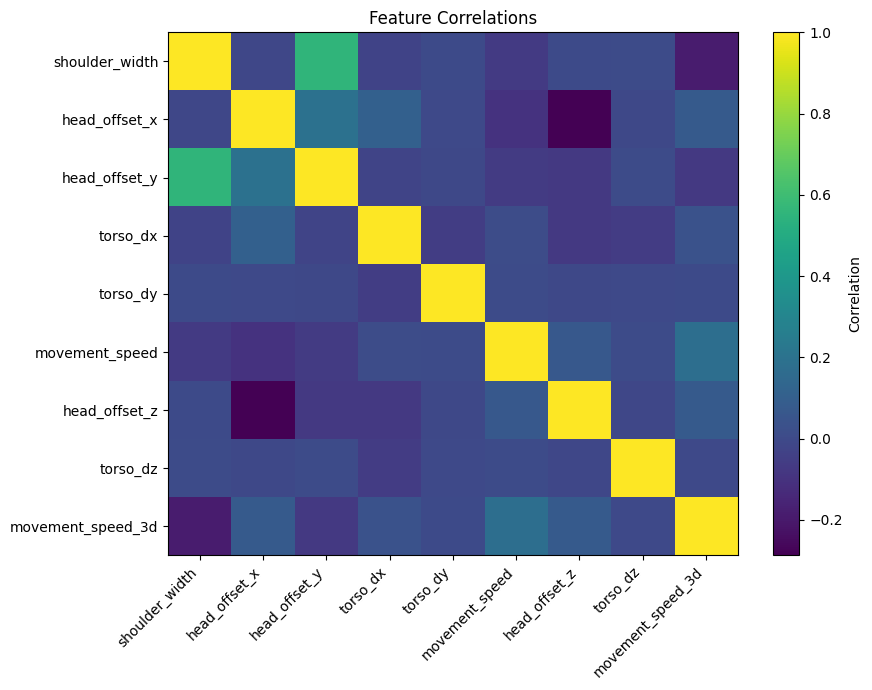

In [14]:
# Feature relationships

correlation = df[feature_columns].corr()

plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar(label="Correlation")
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

Most features show relatively weak linear correlations, while some expected relationships are present. For example, `head_offset_y` and `head_offset_z` are moderately correlated, while `movement_speed` and `movement_speed_3d` capture related aspects of movement.

No features are removed at this stage. The complete representation will first be evaluated by the baseline modelling experiment.

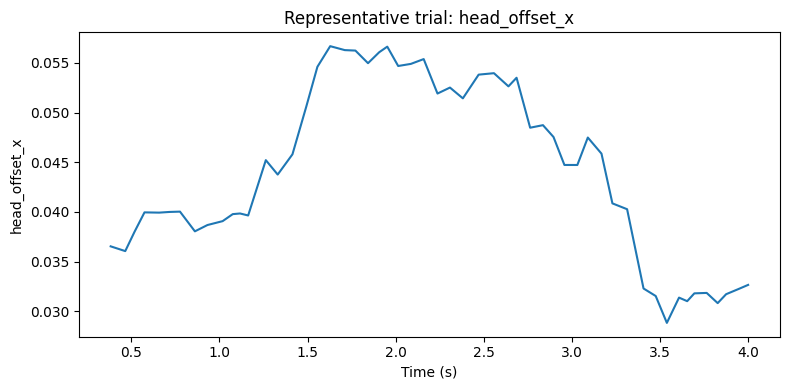

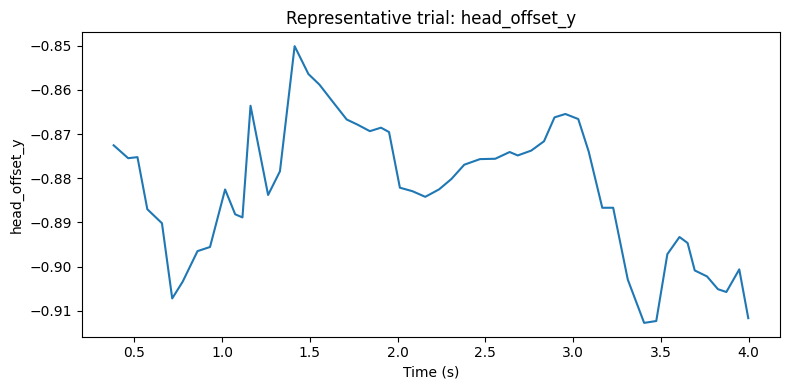

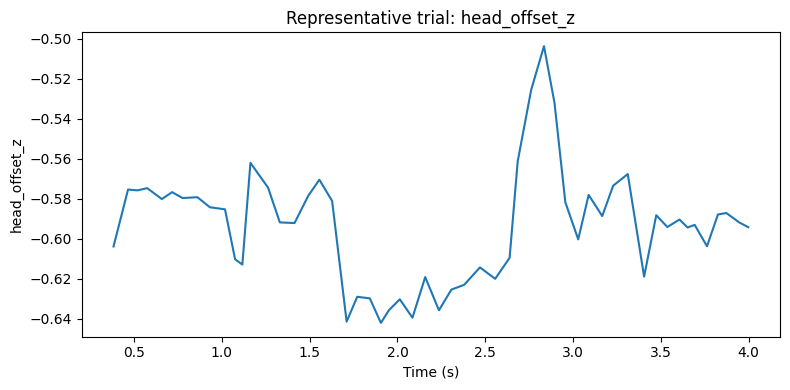

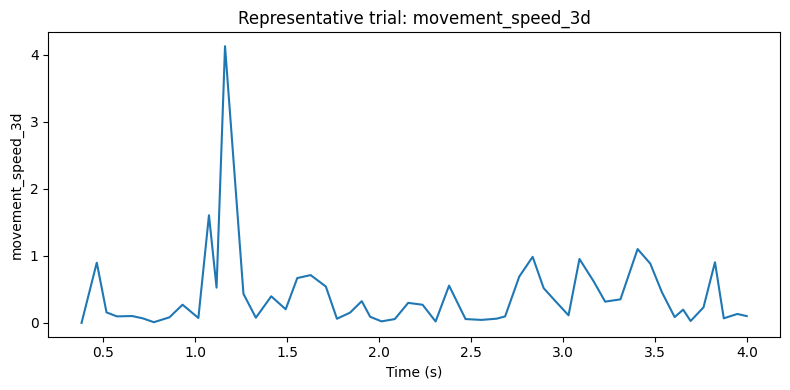

In [15]:
# Temporal example

# Plot a representative trial

example = (
    df[
        (df["participant_id"] == "P01")
        & (df["session_id"] == "S01")
        & (df["trial_id"] == 6)
    ]
    .copy()
)

if example.empty:
    raise ValueError("Representative trial was not found.")

temporal_features = [
    "head_offset_x",
    "head_offset_y",
    "head_offset_z",
    "movement_speed_3d",
]

for feature in temporal_features:
    plt.figure(figsize=(8, 4))

    plt.plot(
        example["timestamp"],
        example[feature]
    )

    plt.title(
        f"Representative trial: {feature}"
    )
    plt.xlabel("Time (s)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

The feature values change over the duration of a trial rather than remaining constant. This supports representing each trial as a temporal sequence in the modelling stage.

## Preliminary Findings

The exploratory analysis gives a basic picture of the current dataset.


### Dataset structure

The dataset contains 2 participants, 2 sessions per participant, and 100 trials across five movement classes. The movement classes are balanced, with 20 trials per class.

Each trial contains 47–60 observations over approximately 3.5–3.6 seconds. The small differences in sequence length are consistent with webcam-based acquisition.

### Movement features

The extracted features show differences between movement classes. In particular, head position and 3D movement speed vary across movements.

These differences indicate that the current feature representation captures information related to the instructed movements. This is descriptive evidence only and does not indicate how well a model will classify unseen trials or participants.

### Participant differences

Some features also vary between participants performing the same movement. The differences are visible in measures such as head position and 3D movement speed.

With only two participants, these observations are preliminary. They may reflect differences in movement style as well as differences in body proportions, camera positioning, or recording conditions.

### Session variation

Movement patterns are not identical between sessions of the same participant. At the same time, several broad movement patterns remain similar across sessions.

This suggests that the dataset contains both within-participant session variation and between-participant variation. The relative importance of these sources of variation cannot be determined from the EDA alone.

### Temporal structure

The features change over time within individual trials, confirming that each trial is a short temporal sequence rather than a collection of identical independent observations.

This supports treating the trial as the basic unit for the subsequent modelling experiment.

### Feature relationships

Most features show relatively weak correlations with one another, with some expected relationships between related measurements.

For example, `head_offset_y` and `head_offset_z` show a moderate correlation, while `movement_speed` and `movement_speed_3d` are also related.

No features are removed based on these correlations alone. Their usefulness will be evaluated during modelling.

### Overall observation

Overall, the dataset shows:

1. differences between movement classes
2. variation between participants
3. variation between sessions
4. temporal changes within trials

These observations provide a starting point for the modelling stage. They do not establish whether a generic or personalised model will perform better.

The next experiment will compare these approaches directly using participant- and trial-aware evaluation.


## Next Step: Modelling

The next stage will evaluate the movement representation using two approaches:

* **Generic model:** trained using data from multiple participants without participant-specific adaptation.
* **Personalised model:** adapted using data from the target participant.

The comparison will focus on model performance under participant- and trial-aware evaluation.

The purpose of the experiment is to determine whether participant-specific adaptation provides a measurable improvement over a generic model, rather than assuming in advance that it will.